In [37]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [38]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# IRIS

In [39]:
IRIS_FILE = "../data/iris.csv"

In [40]:
from utils.utils import load_data
D, L, labels = load_data(IRIS_FILE)

## PCA

In [41]:
M = 2

In [42]:
from utils.utils import get_cov
C = get_cov(D)
print("Covariance Matrix: ")
print(C)

Covariance Matrix: 
[[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


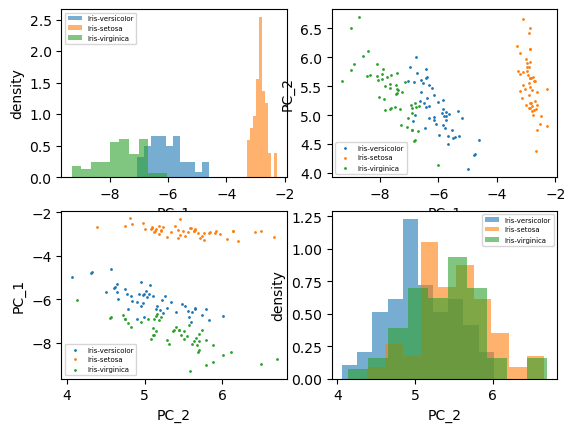

In [43]:
from utils.utils import get_PCs, plot_feature_pairs

P = get_PCs(D, m=M)
Dp_PCA = P.T @ D # Project Data
feature_names = [f'PC_{i}' for i in range(1, M+1)]
plot_feature_pairs(Dp_PCA, L, labels, feature_names)

## LDA

In [44]:
M = 2

In [45]:
from utils.utils import get_class_covariances

Sb, Sw = get_class_covariances(D, L, labels)
print("Between class covariance Matrix (SB): ")
print(Sb)
print("Within Class Covariance Matrix (SW): ")
print(Sw)

Between class covariance Matrix (SB): 
[[ 0.42141422 -0.13301778  1.101656    0.47519556]
 [-0.13301778  0.07563289 -0.38159733 -0.15288444]
 [ 1.101656   -0.38159733  2.91401867  1.24516   ]
 [ 0.47519556 -0.15288444  1.24516     0.53608889]]
Within Class Covariance Matrix (SW): 
[[0.259708   0.09086667 0.164164   0.03763333]
 [0.09086667 0.11308    0.05413867 0.032056  ]
 [0.164164   0.05413867 0.181484   0.041812  ]
 [0.03763333 0.032056   0.041812   0.041044  ]]


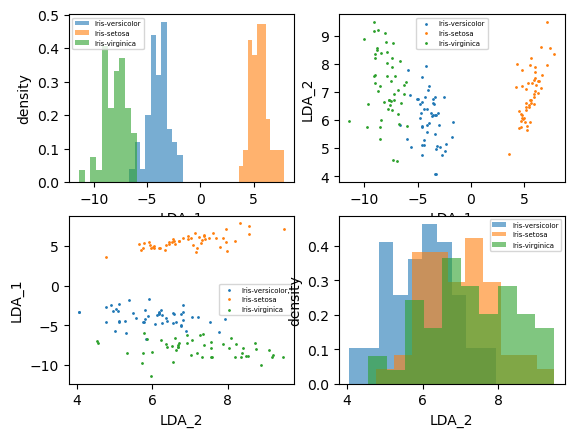

In [46]:
from utils.utils import get_LDs, plot_feature_pairs

W = get_LDs(D, L, labels, m=M)
Dp_LDA = W.T @ D # project data
feature_names = [f'LDA_{i}' for i in range(1, M+1)]
plot_feature_pairs(Dp_LDA, L, labels, feature_names)

## Compare PCA and LDA

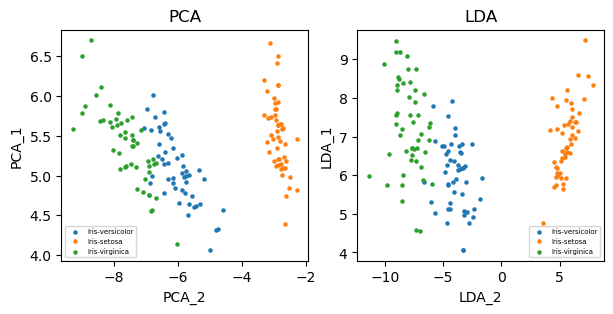

In [47]:
plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("PCA")
for l in labels:
    x = Dp_PCA[0, L==l]
    y = Dp_PCA[1, L==l]
    plt.scatter(x, y, label=l, s=5)
    plt.ylabel("PCA_1")
    plt.xlabel("PCA_2")
plt.legend(fontsize=5)


plt.subplot(1, 2, 2)
plt.title("LDA")
for l in labels:
    x = Dp_LDA[0, L==l]
    y = Dp_LDA[1, L==l]
    plt.scatter(x, y, label=l, s=5)
    plt.ylabel("LDA_1")
    plt.xlabel("LDA_2")
plt.legend(fontsize=5)

plt.show()

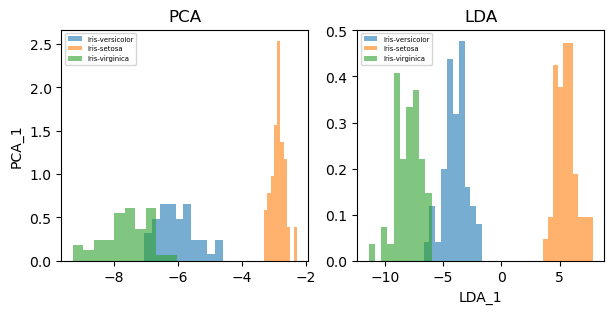

In [48]:
plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("PCA")
for l in labels:
    data = Dp_PCA[0, L==l]
    plt.hist(data, density=True, bins=10, histtype="barstacked", label=l, alpha=0.6)
    plt.ylabel("PCA_1")
plt.legend(fontsize=5)


plt.subplot(1, 2, 2)
plt.title("LDA")
for l in labels:
    data = Dp_LDA[0, L==l]
    plt.hist(data, density=True, bins=10, histtype="barstacked", label=l, alpha=0.6)
    plt.xlabel("LDA_1")
plt.legend(fontsize=5)

plt.show()

## Classification

In [49]:
def load_iris():
    return sklearn.datasets.load_iris()['data'].T, sklearn.datasets.load_iris()['target']
DIris, LIris = load_iris()
D = DIris[:, LIris != 0]
L = LIris[LIris != 0]


In [50]:
from utils.utils import split_db_2to1, vrow
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)
labels = [1, 2]

### LDA

In [51]:
from utils.utils import get_LDs

W = get_LDs(DTR, LTR, labels, 1)
DTR_LDA = W.T @ DTR
DVAL_LDA = W.T @ DVAL

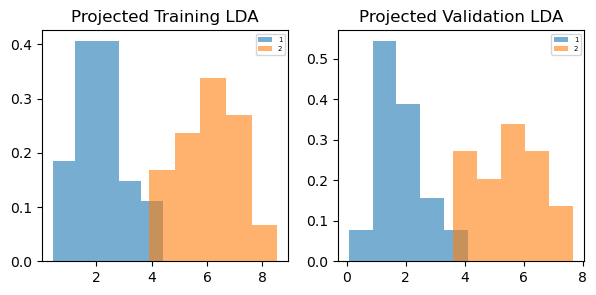

In [52]:
plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("Projected Training LDA")
for l in labels:
    data = DTR_LDA[0, LTR==l]
    plt.hist(data, density=True, bins=5, histtype="barstacked", label=l, alpha=0.6)
plt.legend(fontsize=5)


plt.subplot(1, 2, 2)
plt.title("Projected Validation LDA")
for l in labels:
    data = DVAL_LDA[0, LVAL==l]
    plt.hist(data, density=True, bins=5, histtype="barstacked", label=l, alpha=0.6)
plt.legend(fontsize=5)

plt.show()

In [53]:
from utils.utils import binary_classfication_avgmean

e_LDA, m_LDA, t_LDA = binary_classfication_avgmean(DTR_LDA, LTR, DVAL_LDA, LVAL, 1, 2)

print(e_LDA, "/", LVAL.size)

2 / 34


### PCA

In [54]:
from utils.utils import get_PCs

P = get_PCs(DTR, 1)
P = P * (-1)
DTR_PCA = P.T @ DTR
DVAL_PCA = P.T @ DVAL

In [55]:
from utils.utils import binary_classfication_avgmean

e_PCA, m_PCA, t_PCA = binary_classfication_avgmean(DTR_PCA, LTR, DVAL_PCA, LVAL, 1, 2)

print(e_PCA, "/", LVAL.size)

4 / 34


### PCA + LDA

In [56]:
from utils.utils import get_PCs, get_LDs

P = get_PCs(DTR, 2)
DTR_PCA = P.T @ DTR

W = get_LDs(DTR_PCA, LTR, labels, 1)
DTR_PCA_LDA = W.T @ DTR_PCA
DVAL_PCA_LDA = W.T @ (P.T @ DVAL)

In [57]:
from utils.utils import binary_classfication_avgmean

e_PCA_LDA, m_PCA_LDA, t_PCA_LDA = binary_classfication_avgmean(DTR_PCA_LDA, LTR, DVAL_PCA_LDA, LVAL, 1, 2)

print(e_PCA_LDA, "/", LVAL.size)

2 / 34


### Overview

In [58]:
print("PCA \t\t", e_PCA, "/", LVAL.size)
print("LDA \t\t", e_LDA, "/", LVAL.size)
print("PCA+LDA \t", e_PCA_LDA, "/", LVAL.size)

PCA 		 4 / 34
LDA 		 2 / 34
PCA+LDA 	 2 / 34


(16,) (16,)
(18,) (18,)


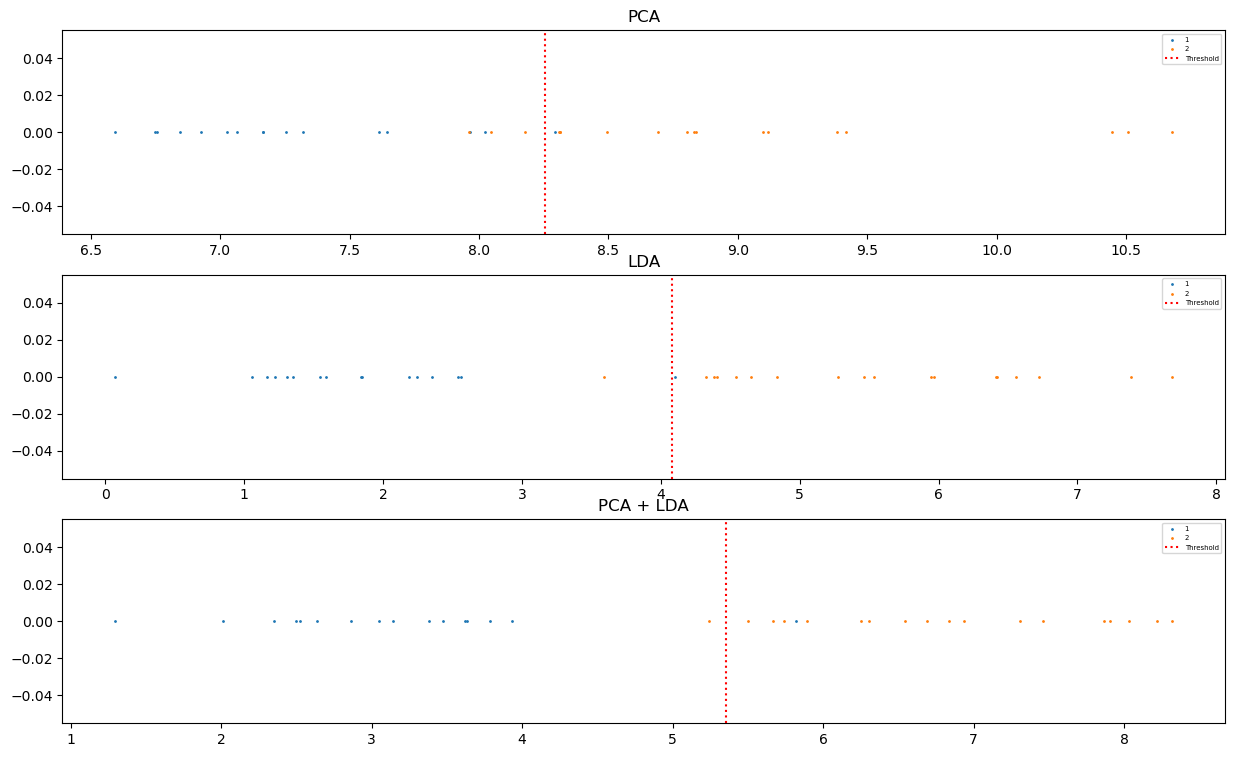

In [59]:
plt.figure(figsize=(15, 9))

plt.subplot(3, 1, 1)
plt.title("PCA")
for l in labels:
    x = DVAL_PCA[0, LVAL==l]
    y = np.zeros(x.shape)
    print(x.shape, y.shape)
    plt.scatter(x, y, label=l, s=1)
plt.axvline(x=t_PCA, linestyle=':', color='red', label='Threshold')
plt.legend(fontsize=5)


plt.subplot(3, 1, 2)
plt.title("LDA")
for l in labels:
    x = DVAL_LDA[0, LVAL==l]
    y = np.zeros(x.shape)
    plt.scatter(x, y, label=l, s=1)
plt.axvline(x=t_LDA, linestyle=':', color='red', label='Threshold')
plt.legend(fontsize=5)

plt.subplot(3, 1, 3)
plt.title("PCA + LDA")
for l in labels:
    x = DVAL_PCA_LDA[0, LVAL==l]
    y = np.zeros(x.shape)
    plt.scatter(x, y, label=l, s=1)
plt.axvline(x=t_PCA_LDA, linestyle=':', color='red', label='Threshold')
plt.legend(fontsize=5)

plt.show()

# Project

In [60]:
PROJECT_FILE = "../data/trainData.txt"

In [61]:
from utils.utils import load_data
D, L, labels = load_data(PROJECT_FILE)
feature_names = [f'F{i}' for i in range(0, D.shape[0])]
L = L.astype(int)
labels = [0, 1]

## 1

Apply PCA and LDA to the project data. Start analyzing the effects of PCA on the features. Plot
the histogram of the projected features for the 6 PCA directions, starting from the principal (largest
variance). What do you observe? What are the effects on the class distribution? Can you spot the
different clusters inside each class?

In [62]:
from utils.utils import get_PCs

P = get_PCs(D, 6)
Dp = P.T @ D

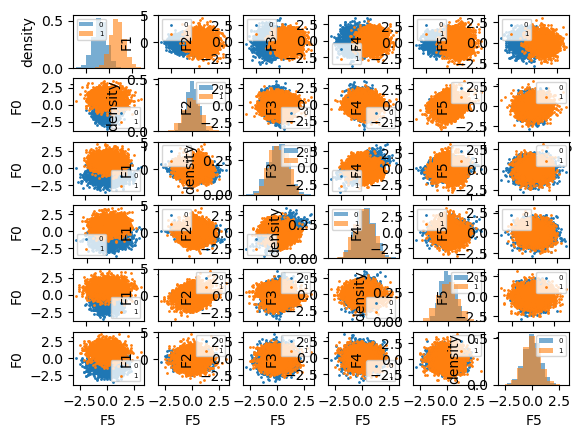

In [ ]:
from utils.utils import plot_featur e_pairs
plot_feature_pairs(Dp, L, labels)

It is observable in the data that PC1 captures best sepparability in the data, beeing the only one that displays 2 peaks in histogram (meaning different means). The scatter plots also indicate the same, evidenced by the fact that clearer clusters can only be observed in plots containing .

The PCA-transformed features show different distribution for individual features and different scatter
plots. However, recall that PCA with 6 dimensions corresponds to just a rotation of the features. Have
the clusters really changed? Have the classes really become “more separated”? (hint: the answer to both
questions is no). This shows us that, while useful, exploratory analysis like histograms and scatter plots
is often not sufficient to understand the global characteristics of our dataset, despite still giving some
useful insights, as we will see in the next laboratories.

## 2

Apply LDA (1 dimensional, since we have just two classes), and compute the histogram of the projected
LDA samples. What do you observe? Do the classes overlap over the found direction? Compared to the
histograms of the 6 features you computed in Laboratory 2, is LDA finding a good direction with little
class overlap? (Note: LDA is not increasing the separation between classes, it’s finding a direction in
the original feature space along which the classes are already well separated).

In [64]:
from utils.utils import get_LDs

W = get_LDs(D, L, labels, 1)
Dp = W.T @ D

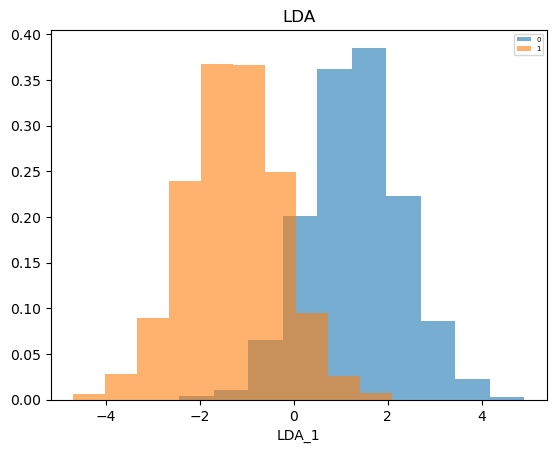

In [65]:
plt.figure()
plt.title("LDA")
for l in labels:
    data = Dp[0, L==l]
    plt.hist(data, density=True, bins=10, histtype="barstacked", label=l, alpha=0.6)
    plt.xlabel("LDA_1")
plt.legend(fontsize=5)

plt.show()

## 3

Try applying LDA for classification. Divide the dataset in model training and validation sets (you can
reuse the previous function to split the dataset). Apply LDA, select the orientation that results in the
projected mean of class True (label 1) being larger than the projected mean of class False (label 0),
and select the threshold as in the previous sections, i.e., as the average of the projected class means.
Compute the predictions on the validation data, and the corresponding error rate.


In [66]:
from utils.utils import split_db_2to1
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)

In [67]:
from utils.utils import get_LDs

W = get_LDs(DTR, LTR, labels, 1)
DTR_LDA = W.T @ DTR
DVAL_LDA = W.T @ DVAL

In [68]:
from utils.utils import binary_classfication_avgmean

e_LDA, m_LDA, t_LDA = binary_classfication_avgmean(DTR_LDA, LTR, DVAL_LDA, LVAL, 0, 1)

print(e_LDA, "/", LVAL.size, " = ", e_LDA/LVAL.size)

186 / 2000  =  0.093


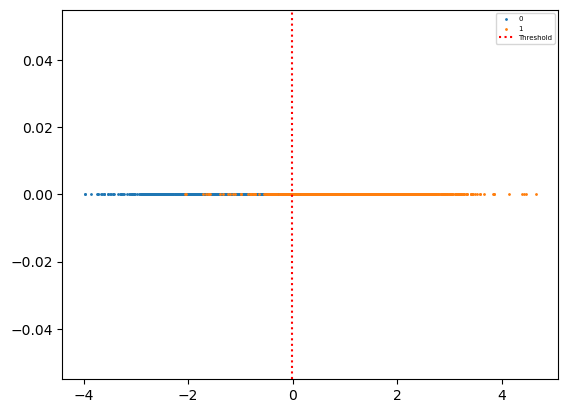

In [69]:
plt.figure()
for l in labels:
    x = DVAL_LDA[0, LVAL==l]
    y = np.zeros(x.shape)
    plt.scatter(x, y, label=l, s=1)
plt.axvline(x=t_LDA, linestyle=':', color='red', label='Threshold')
plt.legend(fontsize=5)

Now try changing the value of the threshold. What do you observe? Can you find values that improve the classification accuracy?
- Thresh = 0.085 leads to less misses 

## 4

Finally, try pre-processing the features with PCA. Apply PCA (estimated on the model training data
only), and then classify the validation data with LDA. Analyze the performance as a function of the
number of PCA dimensions m. What do you observe? Can you find values of m that improve the
accuracy on the validation set? Is PCA beneficial for the task when combined with the LDA classifier?

In [70]:
from utils.utils import get_PCs, get_LDs

P = get_PCs(DTR, 2)
DTR_PCA = P.T @ DTR
DVAL_PCA = P.T @ DVAL

W = get_LDs(DTR_PCA, LTR, labels, 1)
DTR_PCA_LDA = W.T @ DTR_PCA
DVAL_PCA_LDA = W.T @ DVAL_PCA

In [71]:
from utils.utils import binary_classfication_avgmean

e_PCA_LDA, m_PCA_LDA, t_PCA_LDA = binary_classfication_avgmean(DTR_PCA_LDA, LTR, DVAL_PCA_LDA, LVAL, 0, 1)

print(e_PCA_LDA, "/", LVAL.size, " = ", e_PCA_LDA/LVAL.size)

185 / 2000  =  0.0925


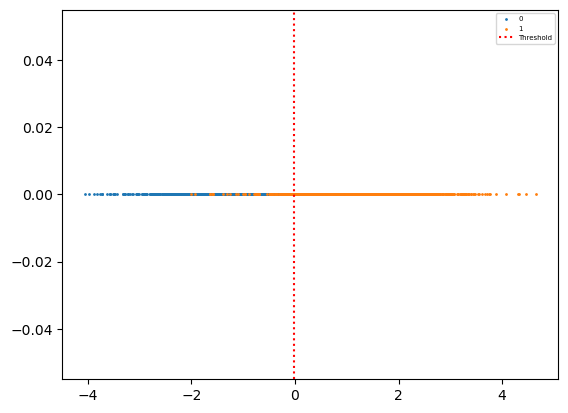

In [72]:
plt.figure()
for l in labels:
    x = DVAL_PCA_LDA[0, LVAL==l]
    y = np.zeros(x.shape)
    plt.scatter(x, y, label=l, s=1)
plt.axvline(x=t_PCA_LDA, linestyle=':', color='red', label='Threshold')
plt.legend(fontsize=5)